
# 31 — Wearable Activity & Depression: Physical Behavior Differences

**Purpose**: NB30 showed that depressed patients have worse glycemic control. This notebook
asks whether depressed patients also **behave differently** — measured by wearable sensors
tracking physical activity, sleep, cardiovascular function, and physiological stress.

**Six wearable metrics are compared between depressed (CES-D-10 ≥ 10) and non-depressed
patients across age groups and diabetes categories:**
1. **Daily steps** — derived from Garmin wearable activity data
2. **Calories burnt** (kcal/day) — active calories from Garmin sensor
3. **Sleep duration** (hours/night) — total sleep time per night
4. **Stress score** — physiological stress index (Garmin HRV-based)
5. **O₂ saturation** (SpO₂, %) — blood oxygen level
6. **Heart rate** (bpm) — average heart rate from wrist sensor
7. **Respiration rate** (rpm) — respiratory rate bonus metric from sensor

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.
All results stay in memory only — no files are written to disk.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year_of_birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — CES-D-10 items
- Azure `{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv` — pre-computed
  per-person averages for all seven wearable metrics (no individual file streaming needed)

---

**Table of Contents**
1. Environment Setup
2. Azure Connection + Core Data (participants, age, CES-D-10)
3. Discover Available Wearable Data
4. Load All Wearable Metrics from Manifest
5. Sleep Data — Status Check
6. Heart Rate, SpO₂, Stress, Respiration — Status Check
7. Merge All Sources
8. Analysis 1 — Overall: Depressed vs Non-Depressed on All Metrics
9. Analysis 2 — By Diabetes Group
10. Analysis 3 — By Age Band
11. Analysis 4 — Full Stratification: Age Band × Diabetes Group
12. Analysis 5 — Regression: Does Depression Independently Predict Wearable Outcomes?
13. Key Findings

---


In [15]:
# ── 1. Environment Setup ────────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels', 'tqdm']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, json, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
GROUP_COLORS = {'Healthy': '#66C2A5', 'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}
DEP_COLORS   = {'Depressed': '#C0392B', 'Non-Depressed': '#2980B9'}

AGE_BAND_EDGES  = [0, 50, 60, 70, 120]
AGE_BAND_LABELS = ['<50', '50–59', '60–69', '70+']

DEPRESSION_CUTOFF = 10
STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

print('Environment ready.')

Environment ready.


In [16]:
# ── 2. Azure Connection + Core Data ────────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    repo_root = str(_cwd.parent if (_cwd.parent / 'config' / 'azure_config.py').exists() else _cwd)
    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

# Participants
print('Loading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

# Age
print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']
print(f'  {len(person):,} rows  age range: {person["age"].min():.0f}–{person["age"].max():.0f}')

# CES-D-10 depression flag
print('\nLoading observation.csv for CES-D-10 ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows')
obs_raw['item_key']    = (obs_raw['observation_source_value']
                          .astype(str).str.split(',', n=1).str[0].str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan

CESD_KEYS = [f'ces{i}' for i in range(1, 11)] + ['cestl']
cesd_obs  = obs_raw[obs_raw['item_key'].isin(CESD_KEYS)].copy()
cesd_wide = (cesd_obs[['person_id', 'item_key', 'value_clean']]
             .pivot_table(index='person_id', columns='item_key',
                          values='value_clean', aggfunc='first'))

if 'cestl' in cesd_wide.columns:
    cesd_wide = cesd_wide.rename(columns={'cestl': 'cesd_total'})
else:
    item_cols = [c for c in cesd_wide.columns if c.startswith('ces')]
    for col in ['ces5', 'ces8']:
        if col in cesd_wide.columns:
            cesd_wide[col] = 3 - cesd_wide[col]
    cesd_wide['cesd_total'] = cesd_wide[item_cols].sum(axis=1, skipna=False)

cesd_out = cesd_wide[['cesd_total']].reset_index()
cesd_out['depressed'] = (cesd_out['cesd_total'] >= DEPRESSION_CUTOFF).astype(float)
cesd_out['dep_label'] = cesd_out['depressed'].map({1.0: 'Depressed', 0.0: 'Non-Depressed'})
print(f'  CES-D-10: {cesd_out["cesd_total"].notna().sum():,} participants')
print(f'  Depression rate: {cesd_out["depressed"].mean()*100:.1f}%  '
      f'({cesd_out["depressed"].sum():.0f} depressed)')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi
Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...
  2,280 rows  age range: 41–94

Loading observation.csv for CES-D-10 ...
  707,126 rows
  CES-D-10: 2,277 participants
  Depression rate: 20.0%  (455 depressed)


In [17]:

# ── 3. Discover Available Wearable Data ────────────────────────────
import re

print('Scanning wearable directories ...')
prefix = f'{STUDY_ID}/dataset/wearable_'
wearable_blobs = [b.name for b in container.list_blobs(name_starts_with=prefix)]
print(f'Total wearable blobs: {len(wearable_blobs):,}')

base = f'{STUDY_ID}/dataset/'
dirs = {}
for b in wearable_blobs:
    rel   = b[len(base):]
    parts = rel.split('/')
    if len(parts) >= 2:
        dirs.setdefault(parts[0], []).append(b)

print('\n─── Wearable directories ───')
for d, blobs in sorted(dirs.items()):
    print(f'  {d}/   ({len(blobs):,} files)')

# Find and preview manifests
manifests = [b for b in wearable_blobs if 'manifest' in b.lower().split('/')[-1]]
print(f'\n─── Manifests ({len(manifests)}) ───')
MANIFEST_INFO = {}
for m in manifests:
    sep = '\t' if m.endswith('.tsv') else ','
    try:
        df_s = load_blob_csv(m, sep=sep, nrows=2)
        MANIFEST_INFO[m] = {'sep': sep, 'cols': df_s.columns.tolist()}
        print(f'  {m.split("/")[-2]}/{m.split("/")[-1]}')
        print(f'    cols: {df_s.columns.tolist()}')
    except Exception as e:
        print(f'  {m}: FAILED — {e}')

# Enumerate unique metric types in individual-file directories
print('\n─── Individual file metric types ({person_id}_{metric}.json) ───')
METRIC_FILE_MAP = {}
for d, blobs in dirs.items():
    for b in blobs:
        fname = b.split('/')[-1]
        m = re.match(r'^(\d+)_(.+)\.json$', fname)
        if m:
            pid, metric = m.group(1), m.group(2)
            METRIC_FILE_MAP.setdefault(d, {}).setdefault(metric, []).append(b)

# Set WEARABLE_DIR to activity monitor (not blood glucose)
WEARABLE_DIR = next(
    (d for d in METRIC_FILE_MAP if 'activity' in d or 'monitor' in d),
    next(iter(METRIC_FILE_MAP), None)
)
for d, metrics in sorted(METRIC_FILE_MAP.items()):
    print(f'\n  {d}/:')
    for metric, blobs in sorted(metrics.items()):
        print(f'    {metric}: {len(blobs):,} files')

print(f'\nWEARABLE_DIR = {WEARABLE_DIR!r}')


Scanning wearable directories ...
Total wearable blobs: 17,491

─── Wearable directories ───
  wearable_activity_monitor/   (15,245 files)
  wearable_blood_glucose/   (2,246 files)

─── Manifests (2) ───
  wearable_activity_monitor/manifest.tsv
    cols: ['person_id', 'wrist_worn_on', 'dominant_hand', 'heartrate_filepath', 'heartrate_record_count', 'average_heartrate_bpm', 'oxygen_saturation_filepath', 'oxygen_saturation_record_count', 'average_oxygen_saturation_pct', 'stress_level_filepath', 'stress_level_record_count', 'average_stress_level', 'sleep_filepath', 'sleep_record_count', 'average_sleep_hours', 'respiratory_rate_filepath', 'respiratory_rate_record_count', 'average_respiratory_rate_bpm', 'physical_activity_filepath', 'physical_activity_num_days', 'average_daily_activity', 'active_calories_filepath', 'active_calories_record_count', 'average_active_calories_kcal', 'sensor_sampling_duration_days', 'manufacturer', 'manufacturer_model_name']
  wearable_blood_glucose/manifest.tsv


In [18]:

# ── 4. Load All Wearable Metrics from Manifest ─────────────────────

ACTIVITY_MANIFEST = f'{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv'

print('Loading wearable_activity_monitor manifest ...')
act_mf = load_blob_csv(ACTIVITY_MANIFEST, sep='\t')
print(f'  {len(act_mf):,} rows × {act_mf.shape[1]} cols')

# Map: source column → (target column, unit scale, plausibility range after scaling)
# average_sleep_hours is stored as a fraction of a 24-hour day (0–1), not hours:
#   0.36 × 24 = 8.64 h/night, 0.41 × 24 = 9.84 h/night — matches typical sleep
COL_MAP = {
    'average_heartrate_bpm':         ('avg_heart_rate',       1,    (30,  220)),
    'average_oxygen_saturation_pct': ('avg_spo2',             1,    (80,  100)),
    'average_stress_level':          ('avg_stress',           1,    (0,   100)),
    'average_sleep_hours':           ('sleep_duration_hours', 24,   (3,    13)),  # ×24 → hours
    'average_respiratory_rate_bpm':  ('avg_respiration',      1,    (4,    60)),
    'average_active_calories_kcal':  ('daily_calories',       1,    (0,  8000)),
    'average_daily_activity':        ('daily_steps',          1,    (0, 80000)),
}

wearable_df = act_mf[['person_id']].copy()
for src, (tgt, scale, (lo, hi)) in COL_MAP.items():
    if src not in act_mf.columns:
        print(f'  ⚠️  column not found in manifest: {src}')
        continue
    s = pd.to_numeric(act_mf[src], errors='coerce') * scale
    s = s.where(s.between(lo, hi))
    wearable_df[tgt] = s
    n = s.notna().sum()
    unit_note = f' (×{scale} to convert units)' if scale != 1 else ''
    print(f'  {src:<40} → {tgt:<25}  {n:,} valid'
          f'  mean={s.mean():.2f}  range={s.min():.2f}–{s.max():.2f}{unit_note}')

print(f'\nwearable_df: {wearable_df.shape}')


Loading wearable_activity_monitor manifest ...
  2,184 rows × 27 cols
  average_heartrate_bpm                    → avg_heart_rate             1,987 valid  mean=74.10  range=30.76–112.86
  average_oxygen_saturation_pct            → avg_spo2                   1,628 valid  mean=91.44  range=82.64–97.67
  average_stress_level                     → avg_stress                 1,987 valid  mean=25.51  range=0.14–74.75
  average_sleep_hours                      → sleep_duration_hours       2,007 valid  mean=9.39  range=5.28–12.96 (×24 to convert units)
  average_respiratory_rate_bpm             → avg_respiration            1,760 valid  mean=8.09  range=4.00–15.99
  average_active_calories_kcal             → daily_calories             2,184 valid  mean=199.22  range=0.00–1640.22
  average_daily_activity                   → daily_steps                2,141 valid  mean=6163.89  range=0.00–25726.54

wearable_df: (2184, 8)


In [19]:

# ── 5. Sleep Data — Status Check ───────────────────────────────────
# sleep_duration_hours was loaded from the manifest in Cell 4.

if 'sleep_duration_hours' in wearable_df.columns:
    slp = wearable_df['sleep_duration_hours'].dropna()
    print(f'Sleep duration: {len(slp):,} participants')
    print(f'  mean={slp.mean():.2f} h  median={slp.median():.2f} h  '
          f'range={slp.min():.2f}–{slp.max():.2f} h')
else:
    print('sleep_duration_hours not loaded — check COL_MAP in Cell 4.')


Sleep duration: 2,007 participants
  mean=9.39 h  median=9.36 h  range=5.28–12.96 h


In [20]:

# ── 6. Heart Rate, SpO₂, Stress, Respiration — Status Check ────────
# All loaded from the manifest in Cell 4.

vitals_info = {
    'avg_heart_rate':   'Heart Rate (bpm)',
    'avg_spo2':         'O₂ Saturation (%)',
    'avg_stress':       'Stress Score',
    'avg_respiration':  'Respiration Rate (rpm)',
}
for col, label in vitals_info.items():
    if col in wearable_df.columns:
        s = wearable_df[col].dropna()
        print(f'{label}: {len(s):,} participants  '
              f'mean={s.mean():.2f}  range={s.min():.2f}–{s.max():.2f}')
    else:
        print(f'{label}: not found')

print(f'\nAll wearable columns: {wearable_df.columns.tolist()}')


Heart Rate (bpm): 1,987 participants  mean=74.10  range=30.76–112.86
O₂ Saturation (%): 1,628 participants  mean=91.44  range=82.64–97.67
Stress Score: 1,987 participants  mean=25.51  range=0.14–74.75
Respiration Rate (rpm): 1,760 participants  mean=8.09  range=4.00–15.99

All wearable columns: ['person_id', 'avg_heart_rate', 'avg_spo2', 'avg_stress', 'sleep_duration_hours', 'avg_respiration', 'daily_calories', 'daily_steps']


In [21]:

# ── 7. Merge All Sources ────────────────────────────────────────────

df = (participants[['person_id', 'study_group_code', 'study_group_label']]
      .merge(person[['person_id', 'age']], on='person_id', how='left')
      .merge(cesd_out[['person_id', 'cesd_total', 'depressed', 'dep_label']],
             on='person_id', how='left'))

# Merge wearable data (produced by Cell 4)
if len(wearable_df) > 0 and 'person_id' in wearable_df.columns:
    wearable_df['person_id'] = wearable_df['person_id'].astype(str)
    df['person_id']           = df['person_id'].astype(str)
    df = df.merge(wearable_df, on='person_id', how='left')

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
df['age_band'] = pd.cut(df['age'], bins=AGE_BAND_EDGES,
                         labels=AGE_BAND_LABELS, right=False)
df['age_band'] = pd.Categorical(df['age_band'], categories=AGE_BAND_LABELS, ordered=True)
df['age_std']  = (df['age'] - df['age'].mean()) / df['age'].std()

# Six target metrics — include any extras that loaded (respiration etc.)
WEARABLE_METRICS = {
    'daily_steps':          'Daily Steps',
    'daily_calories':       'Calories Burnt (kcal/day)',
    'sleep_duration_hours': 'Sleep Duration (hours/night)',
    'avg_stress':           'Stress Score',
    'avg_spo2':             'O₂ Saturation (SpO₂, %)',
    'avg_heart_rate':       'Heart Rate (bpm)',
    'avg_respiration':      'Respiration Rate (rpm)',
}
# Only include metrics that actually have data
AVAILABLE_METRICS = {k: v for k, v in WEARABLE_METRICS.items()
                     if k in df.columns and df[k].notna().sum() > 50}

print(f'Final df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'CES-D-10: {df["cesd_total"].notna().sum():,} | '
      f'Depressed: {df["depressed"].sum():.0f} ({df["depressed"].mean()*100:.1f}%)')
print('\nMetric coverage:')
for m, label in WEARABLE_METRICS.items():
    n    = df[m].notna().sum() if m in df.columns else 0
    flag = '✅' if n > 50 else '❌'
    print(f'  {flag} {label:<38}: {n:,} ({n/len(df)*100:.1f}%)')
print(f'\nAvailable for analysis: {list(AVAILABLE_METRICS.keys())}')
if not AVAILABLE_METRICS:
    print('\n⚠️  No wearable metrics loaded.')
    print('Check Cell 3 output: if metric types were found but values are 0, the JSON field')
    print('names in METRIC_EXTRACTORS (Cell 4) may not match the actual file contents.')
    print('Copy the actual field names from the Cell 3 JSON preview and add them to the')
    print('relevant candidates list in METRIC_EXTRACTORS, then re-run Cells 4–7.')


Final df: 2,280 rows × 16 cols
CES-D-10: 2,277 | Depressed: 455 (20.0%)

Metric coverage:
  ✅ Daily Steps                           : 2,141 (93.9%)
  ✅ Calories Burnt (kcal/day)             : 2,184 (95.8%)
  ✅ Sleep Duration (hours/night)          : 2,007 (88.0%)
  ✅ Stress Score                          : 1,987 (87.1%)
  ✅ O₂ Saturation (SpO₂, %)               : 1,628 (71.4%)
  ✅ Heart Rate (bpm)                      : 1,987 (87.1%)
  ✅ Respiration Rate (rpm)                : 1,760 (77.2%)

Available for analysis: ['daily_steps', 'daily_calories', 'sleep_duration_hours', 'avg_stress', 'avg_spo2', 'avg_heart_rate', 'avg_respiration']


---
## 8. Analysis 1 — Overall: Depressed vs Non-Depressed on All Metrics

> **Question**: Across the full cohort, do depressed patients show significantly different
> wearable activity patterns compared to non-depressed patients?
>
> **Method**: Mann-Whitney U test for each metric. FDR correction (Benjamini-Hochberg)
> across all available metrics.

=== Overall: Depressed vs Non-Depressed — Wearable Metrics ===
                       label  n_dep  mean_dep  mean_nodep  delta_mean     p  p_fdr  significant
                 Daily Steps    434  6597.070    6052.900     544.170 0.079  0.138        False
   Calories Burnt (kcal/day)    440   209.350     196.640      12.710 0.592  0.784        False
Sleep Duration (hours/night)    406     9.380       9.390      -0.010 0.784  0.784        False
                Stress Score    401    27.900      24.900       3.010 0.000  0.000         True
     O₂ Saturation (SpO₂, %)    346    91.470      91.440       0.030 0.769  0.784        False
            Heart Rate (bpm)    400    76.450      73.500       2.950 0.000  0.000         True
      Respiration Rate (rpm)    350     8.380       8.020       0.370 0.005  0.011         True


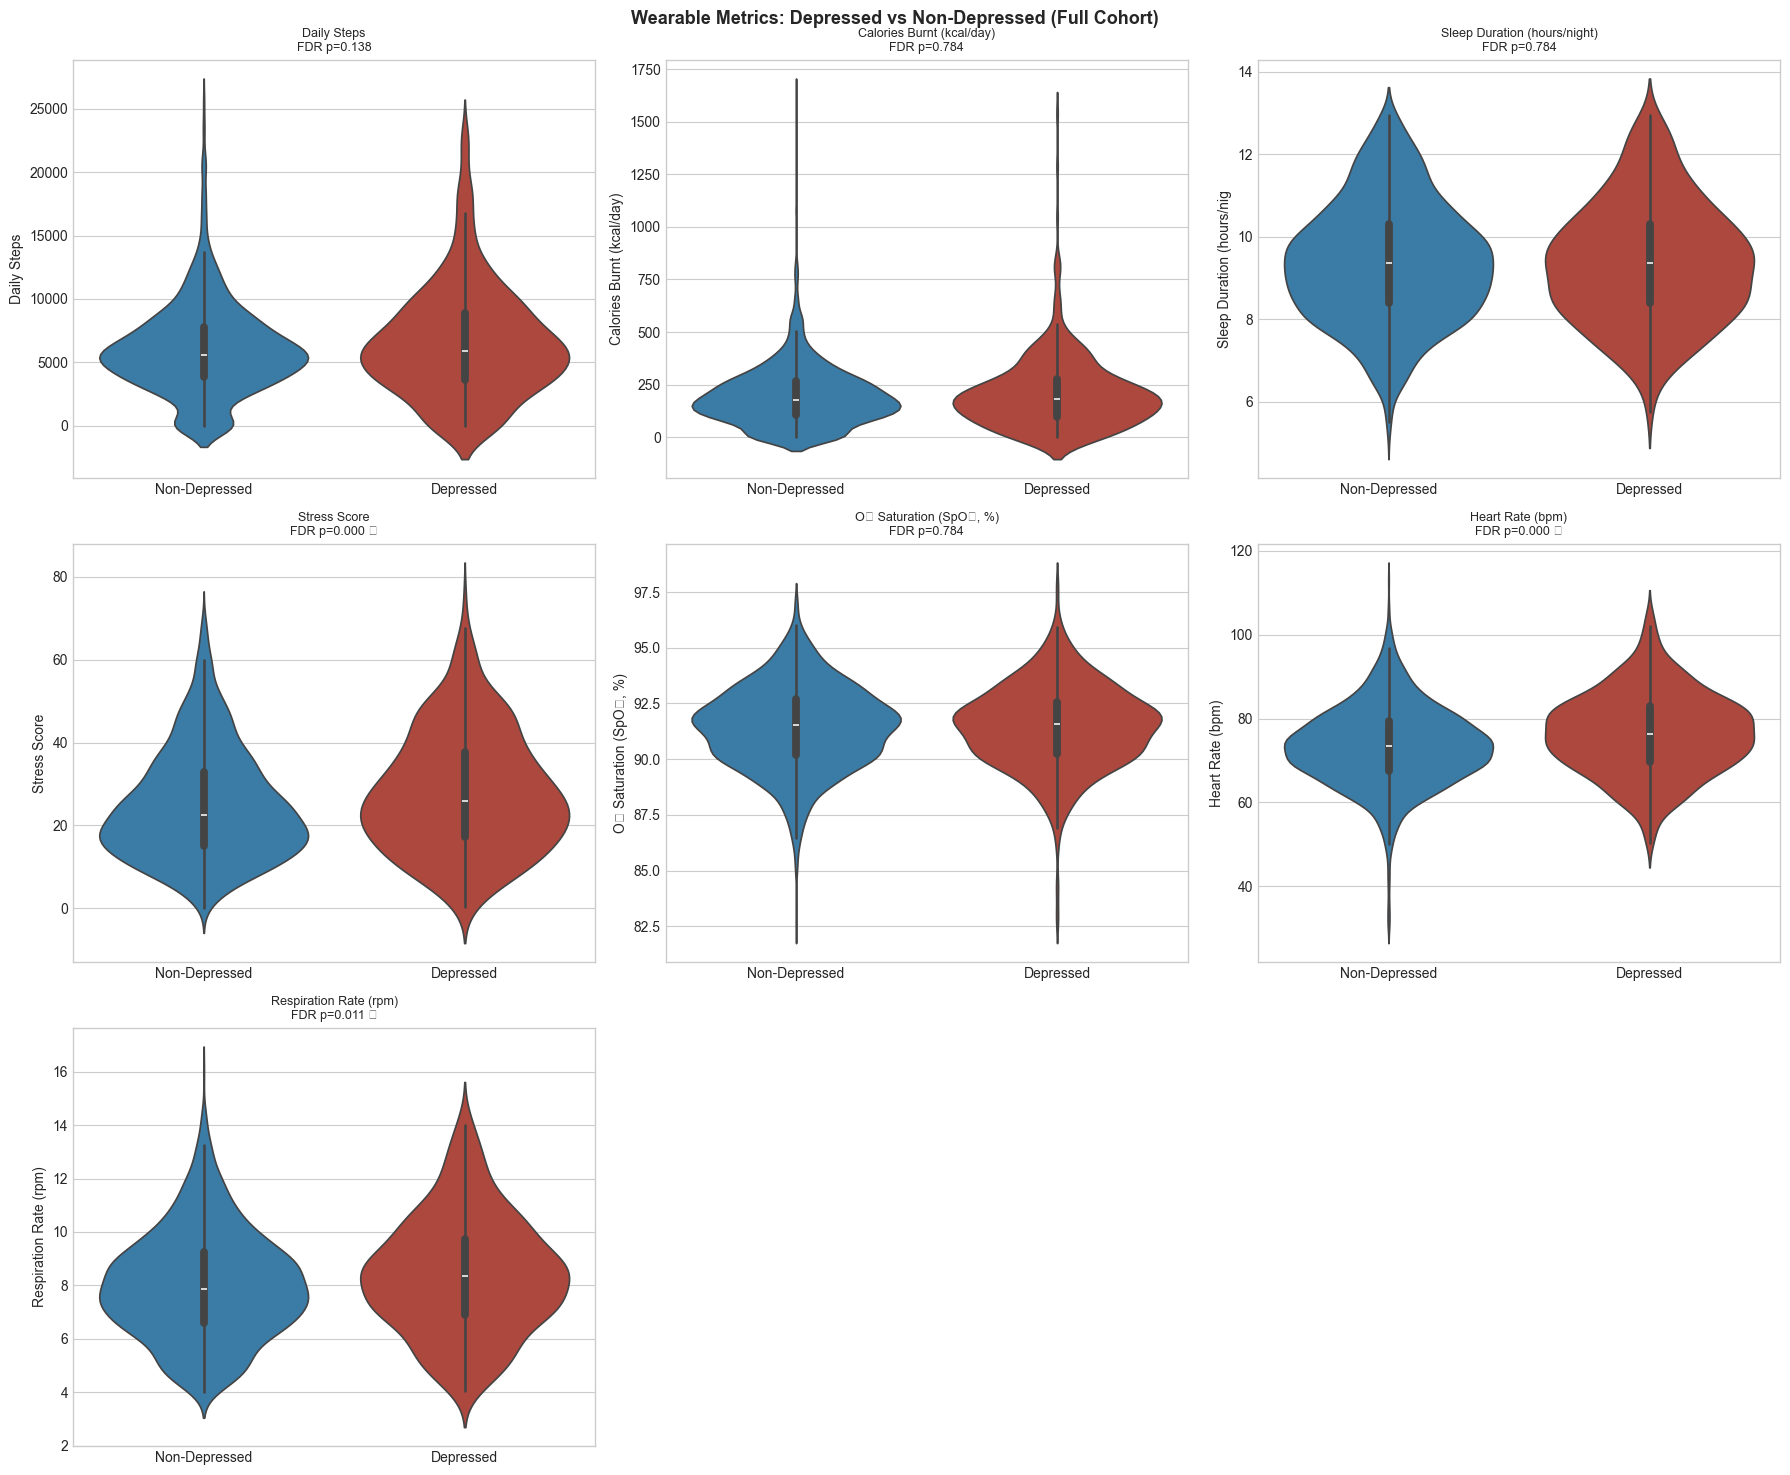

In [22]:

# ── Analysis 1: Overall Depressed vs Non-Depressed ──────────────────

if not AVAILABLE_METRICS:
    print('⚠️  No wearable metrics available — skipping Analysis 1.')
    print('Fix metric loading in Cells 4–7 and re-run from Cell 4.')
else:
    print('=== Overall: Depressed vs Non-Depressed — Wearable Metrics ===')

    overall_records = []
    for metric, label in AVAILABLE_METRICS.items():
        dep   = df[df['depressed'] == 1][metric].dropna()
        nodep = df[df['depressed'] == 0][metric].dropna()
        if len(dep) < 5 or len(nodep) < 5:
            continue
        stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
        overall_records.append({
            'metric':       metric,
            'label':        label,
            'n_dep':        len(dep),
            'n_nodep':      len(nodep),
            'mean_dep':     round(dep.mean(), 2),
            'mean_nodep':   round(nodep.mean(), 2),
            'median_dep':   round(dep.median(), 2),
            'median_nodep': round(nodep.median(), 2),
            'delta_mean':   round(dep.mean() - nodep.mean(), 2),
            'delta_median': round(dep.median() - nodep.median(), 2),
            'p':            round(pval, 5),
        })

    ov_df = pd.DataFrame(overall_records)
    if len(ov_df) > 0:
        _, ov_df['p_fdr'], _, _ = multipletests(ov_df['p'], method='fdr_bh')
        ov_df['p_fdr']       = ov_df['p_fdr'].round(4)
        ov_df['significant'] = ov_df['p_fdr'] < 0.05
        print(ov_df[['label', 'n_dep', 'mean_dep', 'mean_nodep',
                      'delta_mean', 'p', 'p_fdr', 'significant']].to_string(index=False))

    # ── Visualisation ──────────────────────────────────────────────
    n_metrics = len(AVAILABLE_METRICS)
    ncols = min(3, n_metrics)
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    axes = axes.flatten()
    fig.suptitle('Wearable Metrics: Depressed vs Non-Depressed (Full Cohort)',
                 fontsize=13, fontweight='bold')

    for i, (metric, label) in enumerate(AVAILABLE_METRICS.items()):
        ax  = axes[i]
        sub = df.dropna(subset=[metric, 'dep_label'])
        sns.violinplot(data=sub, x='dep_label', y=metric,
                       order=['Non-Depressed', 'Depressed'],
                       palette=['#2980B9', '#C0392B'], inner='box', ax=ax)
        if len(ov_df) > 0:
            row = ov_df[ov_df['metric'] == metric]
            if len(row) > 0:
                p_str = f'FDR p={row["p_fdr"].values[0]:.3f}'
                sig   = ' ✱' if row['significant'].values[0] else ''
                ax.set_title(f'{label[:30]}\n{p_str}{sig}', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel(label[:25])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


---
## 9. Analysis 2 — By Diabetes Group

> **Question**: Within each diabetes group (Healthy, Pre-DM, Oral Med, Insulin), are
> wearable metrics significantly different between depressed and non-depressed patients?
> Does the depression–activity gap scale with disease severity?
>
> **Method**: Mann-Whitney U within each group per metric. FDR correction across all tests.

=== By Diabetes Group: Depressed vs Non-Depressed ===

── Healthy ──
                       label  n_dep  n_nodep  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Daily Steps    116      611  6651.390    6124.010     527.380  0.652        False
   Calories Burnt (kcal/day)    117      624   199.810     197.700       2.110  0.999        False
Sleep Duration (hours/night)    110      587     9.630       9.410       0.220  0.401        False
                Stress Score    110      572    26.880      22.550       4.330  0.025         True
     O₂ Saturation (SpO₂, %)    100      484    91.210      91.580      -0.370  0.330        False
            Heart Rate (bpm)    110      574    75.420      71.880       3.550  0.004         True
      Respiration Rate (rpm)     93      511     8.420       7.870       0.550  0.029         True

── Pre-DM ──
                       label  n_dep  n_nodep  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Daily Ste

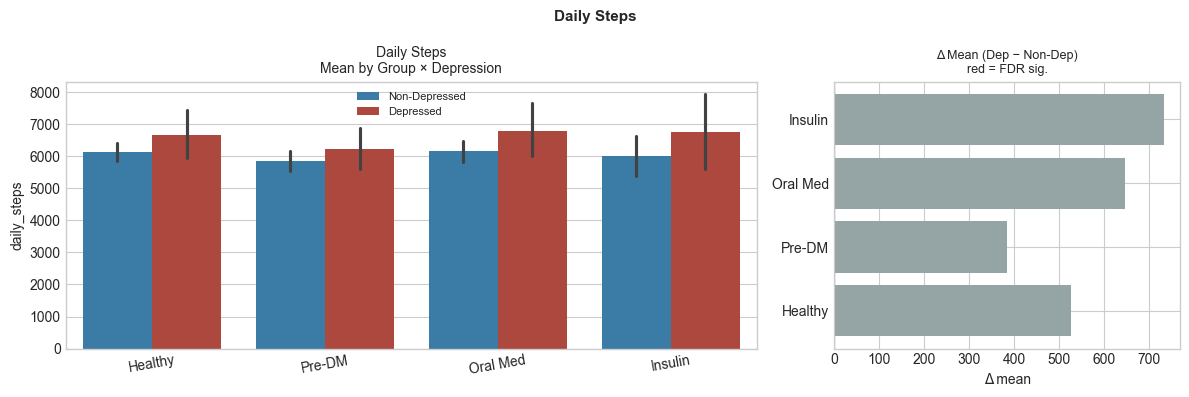

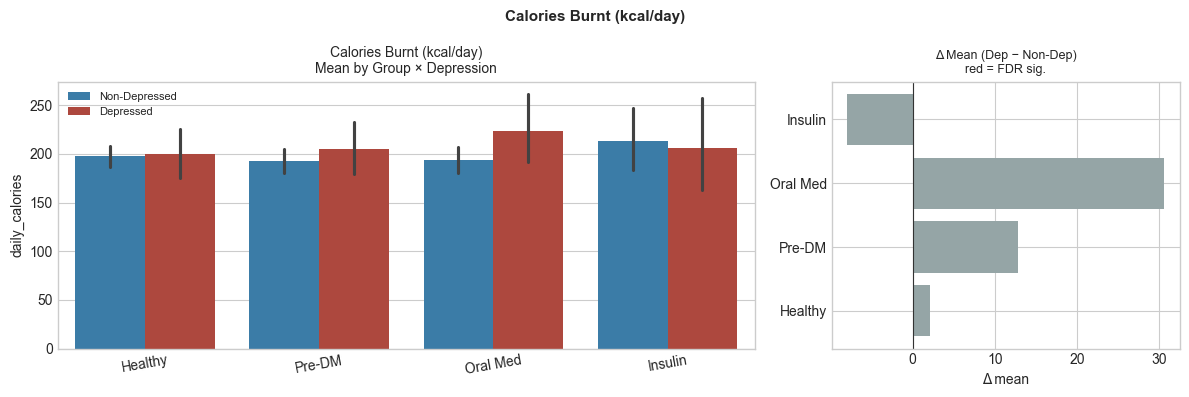

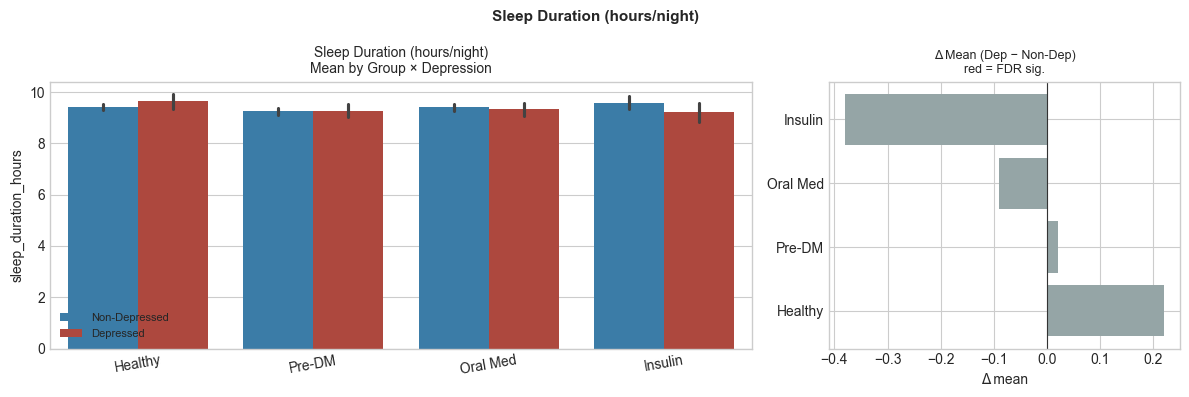

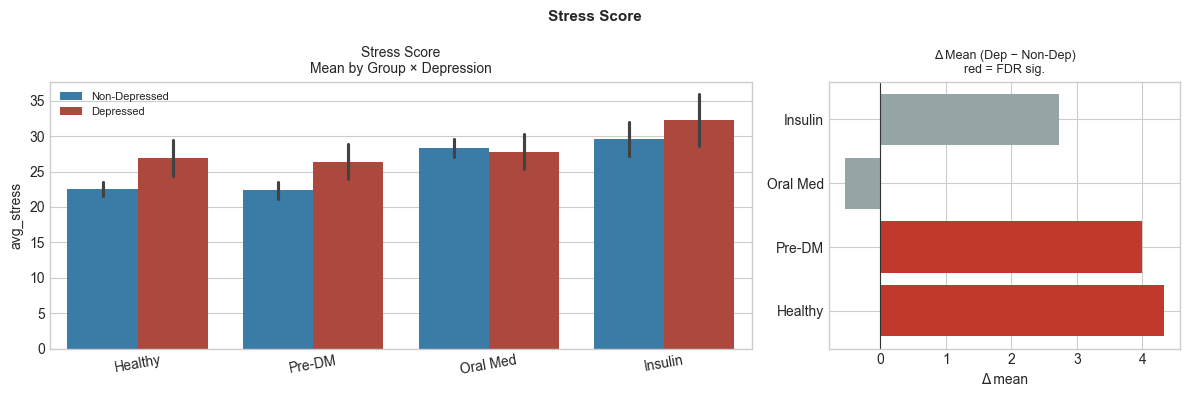

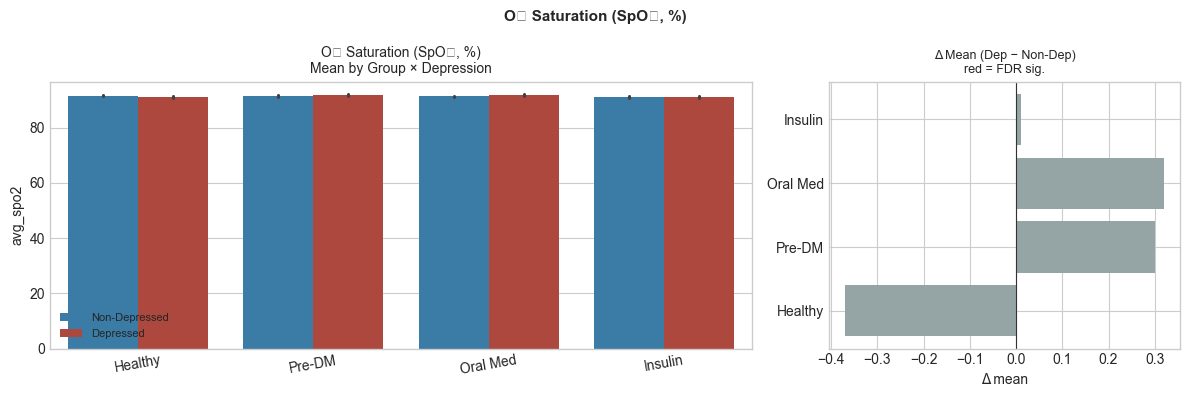

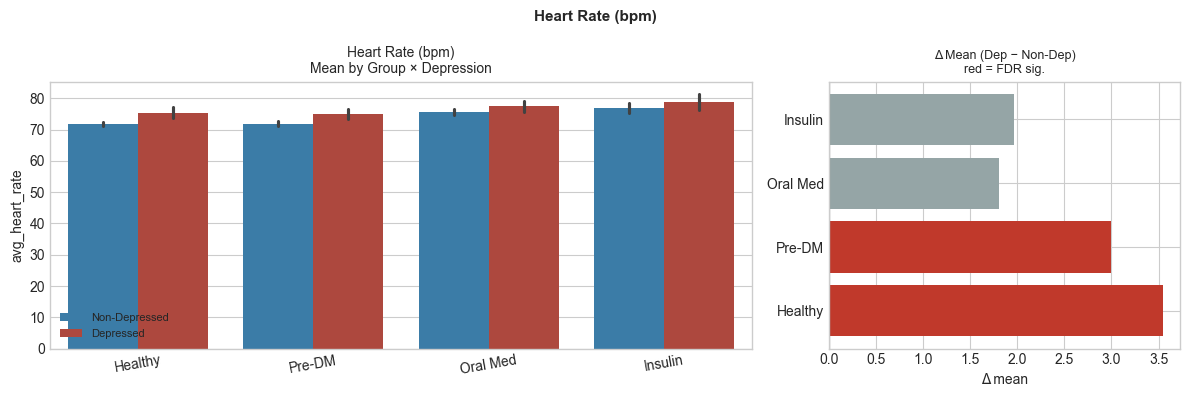

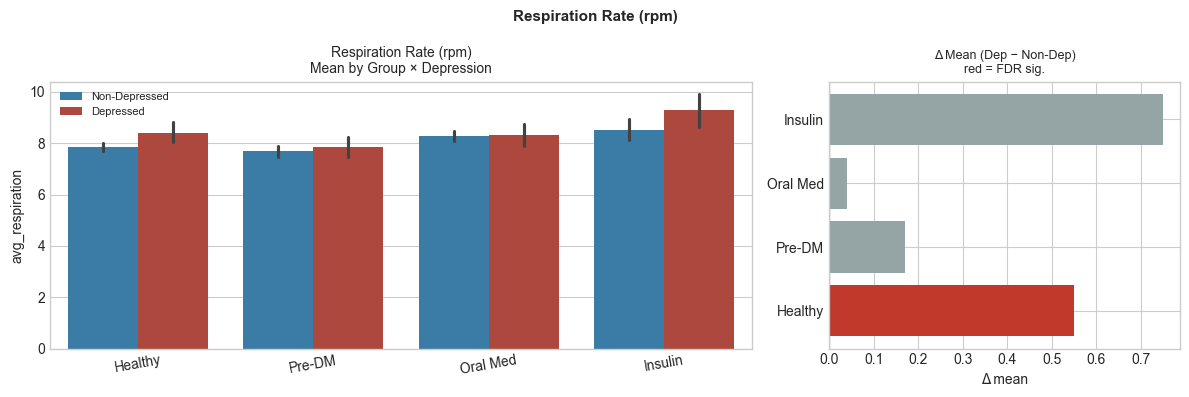

In [23]:

# ── Analysis 2: By Diabetes Group ─────────────────────────────────

if not AVAILABLE_METRICS:
    print('⚠️  No wearable metrics available — skipping Analysis 2.')
else:
    grp_records = []
    for grp in STUDY_GROUP_ORDER:
        sub_grp = df[df['study_group_label'] == grp]
        for metric, label in AVAILABLE_METRICS.items():
            dep   = sub_grp[sub_grp['depressed'] == 1][metric].dropna()
            nodep = sub_grp[sub_grp['depressed'] == 0][metric].dropna()
            if len(dep) < 5 or len(nodep) < 5:
                continue
            stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
            grp_records.append({
                'group': grp, 'metric': metric, 'label': label,
                'n_dep': len(dep), 'n_nodep': len(nodep),
                'mean_dep':   round(dep.mean(), 2),
                'mean_nodep': round(nodep.mean(), 2),
                'delta_mean': round(dep.mean() - nodep.mean(), 2),
                'p': round(pval, 5),
            })

    grp_df = pd.DataFrame(grp_records)
    if len(grp_df) > 0:
        _, grp_df['p_fdr'], _, _ = multipletests(grp_df['p'], method='fdr_bh')
        grp_df['p_fdr']       = grp_df['p_fdr'].round(4)
        grp_df['significant'] = grp_df['p_fdr'] < 0.05

        print('=== By Diabetes Group: Depressed vs Non-Depressed ===')
        for grp in STUDY_GROUP_ORDER:
            sub = grp_df[grp_df['group'] == grp]
            if len(sub) == 0:
                continue
            print(f'\n── {grp} ──')
            print(sub[['label', 'n_dep', 'n_nodep', 'mean_dep', 'mean_nodep',
                        'delta_mean', 'p_fdr', 'significant']].to_string(index=False))

    # ── Delta bar chart per metric ─────────────────────────────────
    if len(grp_df) > 0:
        for metric, label in AVAILABLE_METRICS.items():
            sub = grp_df[grp_df['metric'] == metric]
            if len(sub) == 0:
                continue
            fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                                      gridspec_kw={'width_ratios': [2, 1]})
            raw_sub = df.dropna(subset=[metric, 'dep_label', 'study_group_label'])
            sns.barplot(data=raw_sub, x='study_group_label', y=metric, hue='dep_label',
                        order=STUDY_GROUP_ORDER, hue_order=['Non-Depressed', 'Depressed'],
                        palette=['#2980B9', '#C0392B'], ax=axes[0], errorbar='ci')
            axes[0].set_title(f'{label}\nMean by Group × Depression', fontsize=10)
            axes[0].set_xlabel(''); axes[0].legend(title='', fontsize=8)
            axes[0].tick_params(axis='x', rotation=10)
            axes[1].barh(sub['group'], sub['delta_mean'],
                         color=['#C0392B' if s else '#95A5A6' for s in sub['significant']])
            axes[1].axvline(0, color='#333', lw=0.8)
            axes[1].set_title('Δ Mean (Dep − Non-Dep)\nred = FDR sig.', fontsize=9)
            axes[1].set_xlabel('Δ mean')
            plt.suptitle(label, fontsize=11, fontweight='bold')
            plt.tight_layout()
            plt.show()


---
### Bootstrap robustness check — accounting for class imbalance

> The depressed subgroup is much smaller than the non-depressed one, and smallest of all in
> the **Insulin** group — so a single p-value can hide how *uncertain* each group's estimate is.
> Here we resample each subgroup **with replacement** (5,000×) to get a 95% confidence interval
> for the depressed − non-depressed difference. **Wide CIs (especially Insulin) flag
> low-confidence results driven by small n; CIs that exclude 0 are robust.** The Mann-Whitney /
> FDR tests above are kept — this adds an honest effect-size interval. (Bootstrap, not SMOTE:
> we resample the *real* patients rather than fabricating synthetic ones, which would distort
> these estimates.)

In [24]:
# ── Bootstrap 95% CI for depressed − non-depressed difference (handles imbalance) ──
def bootstrap_diff_ci(a, b, n_boot=5000, seed=0, stat=np.mean):
    """95% percentile CI + two-sided bootstrap p for stat(a) - stat(b), resampling reals only."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    rng = np.random.default_rng(seed)
    boots = np.array([stat(rng.choice(a, a.size, True)) - stat(rng.choice(b, b.size, True))
                      for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    p_boot = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
    return stat(a) - stat(b), lo, hi, p_boot

boot_records = []
for grp in STUDY_GROUP_ORDER:
    sub_grp = df[df['study_group_label'] == grp]
    for metric, label in AVAILABLE_METRICS.items():
        dep   = sub_grp[sub_grp['depressed'] == 1][metric].dropna().values
        nodep = sub_grp[sub_grp['depressed'] == 0][metric].dropna().values
        if len(dep) < 5 or len(nodep) < 5:
            continue
        d, lo, hi, pb = bootstrap_diff_ci(dep, nodep)
        boot_records.append({'group': grp, 'metric': label,
                             'n_dep': len(dep), 'n_nodep': len(nodep),
                             'delta': round(d, 2),
                             'ci_low': round(lo, 2), 'ci_high': round(hi, 2),
                             'CI_excludes_0': not (lo <= 0 <= hi),
                             'boot_p': round(pb, 4)})
boot_df = pd.DataFrame(boot_records)
print('=== Bootstrap 95% CI: depressed − non-depressed difference (by group × metric) ===')
print('(CI excludes 0 = robust; wide CI = low confidence from small/imbalanced n)\n')
for grp in STUDY_GROUP_ORDER:
    sub = boot_df[boot_df['group'] == grp]
    if len(sub) == 0:
        continue
    print(f'── {grp} ──')
    print(sub[['metric', 'n_dep', 'n_nodep', 'delta', 'ci_low', 'ci_high',
               'CI_excludes_0', 'boot_p']].to_string(index=False))
    print()

# Make the imbalance visible: average CI width per group (wider = more undercoverage uncertainty)
boot_df['ci_width'] = boot_df['ci_high'] - boot_df['ci_low']
print('Mean bootstrap CI width by group (wider = more uncertainty from undercoverage):')
print(boot_df.groupby('group', observed=True)['ci_width'].mean()
      .reindex(STUDY_GROUP_ORDER).round(2).to_string())
n_robust = int(boot_df['CI_excludes_0'].sum())
print(f'\n{n_robust} of {len(boot_df)} group × metric comparisons have a 95% CI excluding 0 (robust to imbalance).')

=== Bootstrap 95% CI: depressed − non-depressed difference (by group × metric) ===
(CI excludes 0 = robust; wide CI = low confidence from small/imbalanced n)

── Healthy ──
                      metric  n_dep  n_nodep   delta   ci_low  ci_high  CI_excludes_0  boot_p
                 Daily Steps    116      611 527.380 -264.980 1315.150          False   0.190
   Calories Burnt (kcal/day)    117      624   2.110  -22.820   29.430          False   0.892
Sleep Duration (hours/night)    110      587   0.220   -0.080    0.510          False   0.145
                Stress Score    110      572   4.330    1.580    7.160           True   0.003
     O₂ Saturation (SpO₂, %)    100      484  -0.370   -0.750    0.020          False   0.062
            Heart Rate (bpm)    110      574   3.550    1.630    5.490           True   0.000
      Respiration Rate (rpm)     93      511   0.550    0.130    0.960           True   0.013

── Pre-DM ──
                      metric  n_dep  n_nodep   delta   ci_low

---
## 10. Analysis 3 — By Age Band

> **Question**: Within each age group (<50, 50–59, 60–69, 70+), do depressed patients
> show different wearable activity patterns? Given that younger patients have higher
> depression rates (NB29) and may also have different baseline activity levels, age
> stratification is important.
>
> **Method**: Mann-Whitney U within each age band per metric. FDR-corrected.

=== By Age Band: Depressed vs Non-Depressed ===

── <50  (depressed n=124, non-dep n=296) ──
                       label  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Daily Steps  7599.690    7427.800     171.890  0.901        False
   Calories Burnt (kcal/day)   260.900     238.550      22.350  0.751        False
Sleep Duration (hours/night)     9.540       9.690      -0.150  0.487        False
                Stress Score    29.020      26.780       2.240  0.335        False
     O₂ Saturation (SpO₂, %)    91.420      91.800      -0.380  0.359        False
            Heart Rate (bpm)    79.340      76.990       2.350  0.217        False
      Respiration Rate (rpm)     8.100       7.950       0.140  0.751        False

── 50–59  (depressed n=143, non-dep n=420) ──
                       label  mean_dep  mean_nodep  delta_mean  p_fdr  significant
                 Daily Steps  6764.640    6903.500    -138.860  0.570        False
   Calories Burnt (kcal/day)  

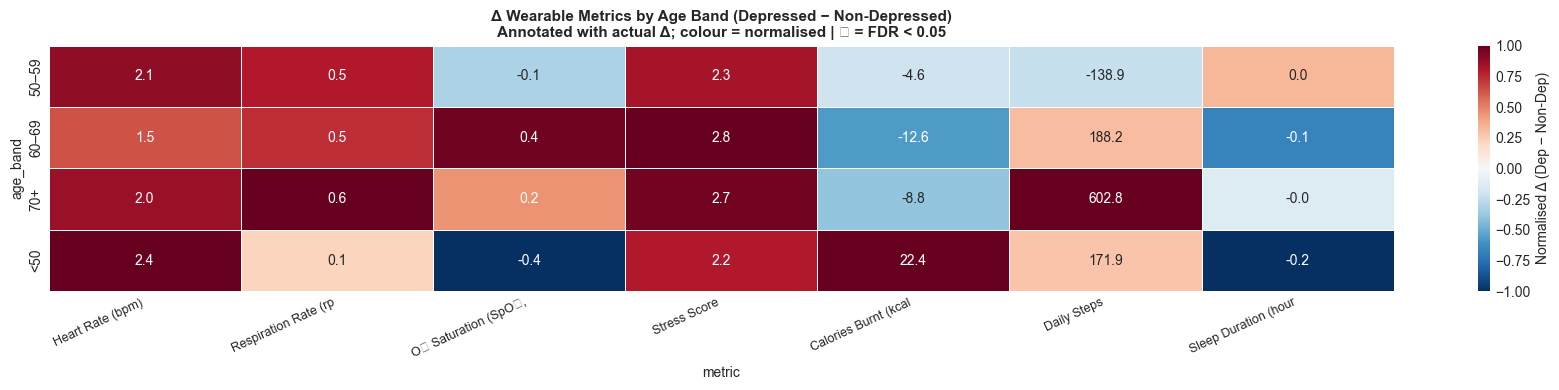

In [25]:
# ── Analysis 3: By Age Band ─────────────────────────────────────────

age_records = []
for band in AGE_BAND_LABELS:
    sub_band = df[df['age_band'] == band]
    for metric, label in AVAILABLE_METRICS.items():
        dep   = sub_band[sub_band['depressed'] == 1][metric].dropna()
        nodep = sub_band[sub_band['depressed'] == 0][metric].dropna()
        if len(dep) < 5 or len(nodep) < 5:
            continue
        stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
        age_records.append({
            'age_band': band, 'metric': metric, 'label': label,
            'n_dep': len(dep), 'n_nodep': len(nodep),
            'mean_dep':   round(dep.mean(), 2),
            'mean_nodep': round(nodep.mean(), 2),
            'delta_mean': round(dep.mean() - nodep.mean(), 2),
            'p': round(pval, 5),
        })

age_df = pd.DataFrame(age_records)
if len(age_df) > 0:
    _, age_df['p_fdr'], _, _ = multipletests(age_df['p'], method='fdr_bh')
    age_df['p_fdr']       = age_df['p_fdr'].round(4)
    age_df['significant'] = age_df['p_fdr'] < 0.05

    print('=== By Age Band: Depressed vs Non-Depressed ===')
    for band in AGE_BAND_LABELS:
        sub = age_df[age_df['age_band'] == band]
        if len(sub) == 0:
            continue
        dep_n   = df[(df['age_band'] == band) & (df['depressed'] == 1)]['depressed'].count()
        nodep_n = df[(df['age_band'] == band) & (df['depressed'] == 0)]['depressed'].count()
        print(f'\n── {band}  (depressed n={dep_n}, non-dep n={nodep_n}) ──')
        print(sub[['label', 'mean_dep', 'mean_nodep',
                    'delta_mean', 'p_fdr', 'significant']].to_string(index=False))

# ── Heatmap of delta by age band × metric ─────────────────────────
if len(age_df) > 0 and len(AVAILABLE_METRICS) > 1:
    hm_delta = age_df.pivot_table(index='age_band', columns='metric', values='delta_mean')
    # Normalize each metric's delta so color scale is comparable
    hm_norm = hm_delta.div(hm_delta.abs().max(axis=0), axis=1)

    fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(AVAILABLE_METRICS)), 4))
    sns.heatmap(hm_norm, annot=hm_delta.round(1), fmt='.1f',
                cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Normalised Δ (Dep − Non-Dep)'})
    # Mark significant cells
    hm_sig = age_df.pivot_table(index='age_band', columns='metric', values='significant')
    for i, band in enumerate(AGE_BAND_LABELS):
        for j, m in enumerate(AVAILABLE_METRICS.keys()):
            if m in hm_sig.columns and band in hm_sig.index:
                if hm_sig.loc[band, m]:
                    ax.text(j + 0.85, i + 0.25, '✱', fontsize=12, color='black')
    ax.set_xticklabels([WEARABLE_METRICS.get(c, c)[:20] for c in hm_norm.columns],
                        rotation=25, ha='right', fontsize=9)
    ax.set_title('Δ Wearable Metrics by Age Band (Depressed − Non-Depressed)\n'
                 'Annotated with actual Δ; colour = normalised | ✱ = FDR < 0.05',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 11. Analysis 4 — Full Stratification: Age Band × Diabetes Group

> **Question**: Within each combination of age band and diabetes category, do depressed
> patients show different wearable behavior? Which specific cells show the largest gaps?
>
> **Method**: Mann-Whitney U in each (age band × group) cell per metric. FDR-corrected
> across all testable cells.

=== Significant cells (FDR < 0.05) ===
No individual age × group cells reach FDR < 0.05.


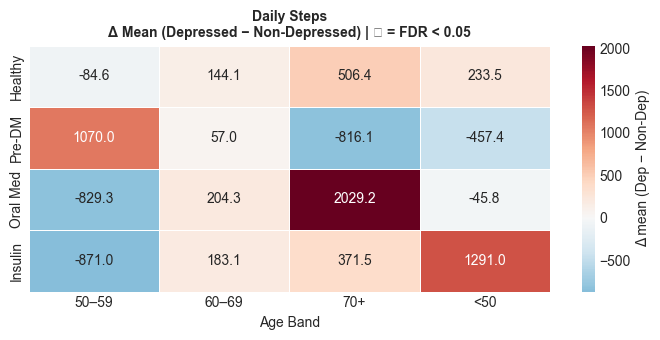

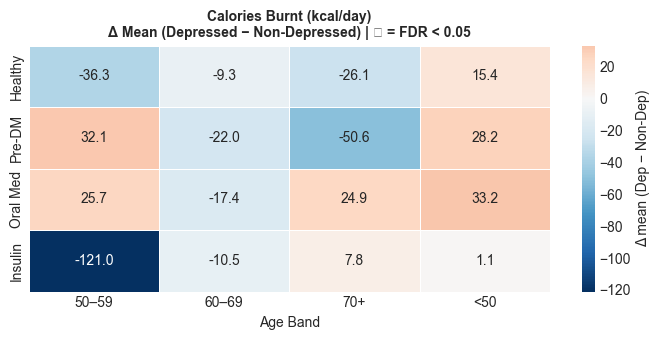

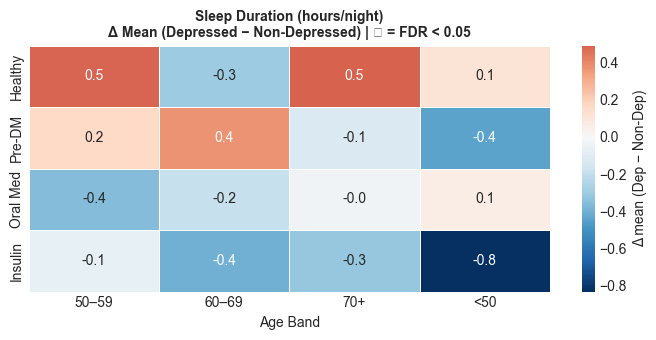

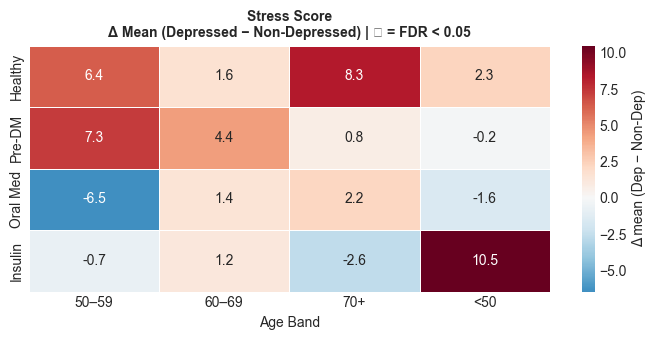

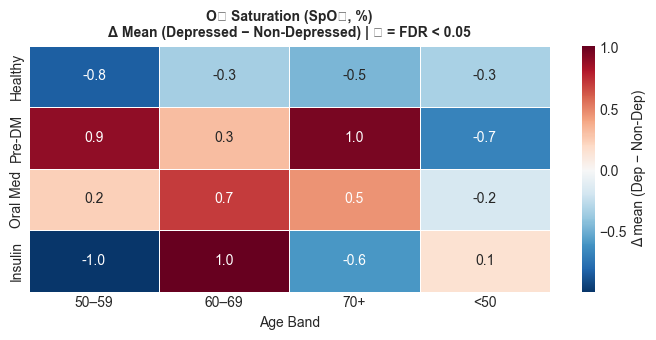

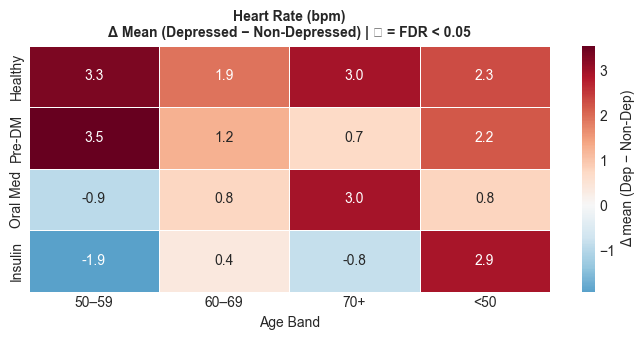

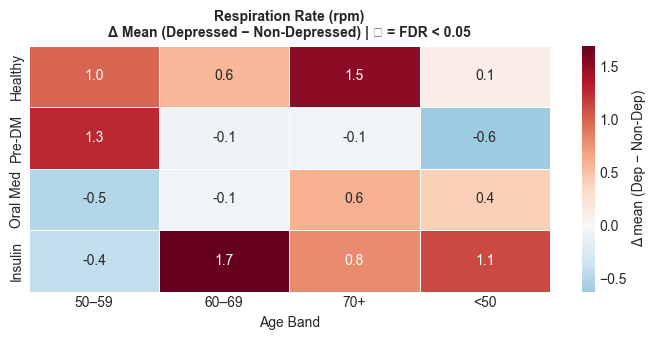

In [26]:
# ── Analysis 4: Full Age × Group Stratification ─────────────────────

strat_records = []
for band in AGE_BAND_LABELS:
    for grp in STUDY_GROUP_ORDER:
        cell = df[(df['age_band'] == band) & (df['study_group_label'] == grp)]
        for metric, label in AVAILABLE_METRICS.items():
            dep   = cell[cell['depressed'] == 1][metric].dropna()
            nodep = cell[cell['depressed'] == 0][metric].dropna()
            if len(dep) < 5 or len(nodep) < 5:
                strat_records.append({
                    'age_band': band, 'group': grp, 'metric': metric, 'label': label,
                    'n_dep': len(dep), 'n_nodep': len(nodep),
                    'mean_dep': np.nan, 'mean_nodep': np.nan,
                    'delta_mean': np.nan, 'p': np.nan, 'note': 'n<5'
                })
                continue
            stat, pval = mannwhitneyu(dep, nodep, alternative='two-sided')
            strat_records.append({
                'age_band': band, 'group': grp, 'metric': metric, 'label': label,
                'n_dep': len(dep), 'n_nodep': len(nodep),
                'mean_dep':   round(dep.mean(), 2),
                'mean_nodep': round(nodep.mean(), 2),
                'delta_mean': round(dep.mean() - nodep.mean(), 2),
                'p': round(pval, 5), 'note': ''
            })

strat_df = pd.DataFrame(strat_records)
testable  = strat_df['p'].notna()
if testable.sum() > 0:
    _, strat_df.loc[testable, 'p_fdr'], _, _ = multipletests(
        strat_df.loc[testable, 'p'], method='fdr_bh')
if 'p_fdr' not in strat_df.columns:
    strat_df['p_fdr'] = np.nan
strat_df['significant'] = strat_df['p_fdr'] < 0.05

print('=== Significant cells (FDR < 0.05) ===')
sig = strat_df[strat_df['significant'] == True]
if len(sig) > 0:
    print(sig[['age_band', 'group', 'label', 'n_dep', 'n_nodep',
               'mean_dep', 'mean_nodep', 'delta_mean', 'p_fdr']].to_string(index=False))
else:
    print('No individual age × group cells reach FDR < 0.05.')

# ── Heatmaps: one per metric ───────────────────────────────────────
for metric, label in AVAILABLE_METRICS.items():
    sub = strat_df[strat_df['metric'] == metric]
    piv = sub.pivot_table(index='group', columns='age_band',
                           values='delta_mean', aggfunc='first')
    piv = piv.reindex(index=STUDY_GROUP_ORDER)
    if piv.empty:
        continue
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Δ mean (Dep − Non-Dep)'})
    sig_sub = sub[sub['significant'] == True]
    for _, row in sig_sub.iterrows():
        if row['age_band'] in piv.columns and row['group'] in piv.index:
            j = list(piv.columns).index(row['age_band'])
            i = list(piv.index).index(row['group'])
            ax.text(j + 0.85, i + 0.25, '✱', fontsize=12, color='black')
    ax.set_title(f'{label}\nΔ Mean (Depressed − Non-Depressed) | ✱ = FDR < 0.05',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Age Band'); ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

---
## 12. Analysis 5 — Regression: Does Depression Independently Predict Wearable Outcomes?

> **Question**: After controlling for diabetes group and age, does depression status still
> independently predict wearable outcomes? Is the depression effect the same across
> all diabetes groups?
>
> **Method**: OLS for each metric: `metric ~ depressed + study_group_code + age_std`.
> Also tests the group × depression interaction to detect severity-dependent effects.

=== OLS Regression: metric ~ depressed + group_code + age_std ===

── Daily Steps (n=2,140) ──
  R²=0.0712
  depressed  raw coef=+102.197  std β=+0.027  p=0.6153  ns
  group_code coef=104.942  p=0.1823
  age_std    coef=-1021.434  p=0.0000
  Interaction (dep × group) p=0.5483  ns

── Calories Burnt (kcal/day) (n=2,183) ──
  R²=0.0598
  depressed  raw coef=-3.386  std β=-0.023  p=0.6697  ns
  group_code coef=5.483  p=0.0739
  age_std    coef=-36.917  p=0.0000
  Interaction (dep × group) p=0.6214  ns

── Sleep Duration (hours/night) (n=2,006) ──
  R²=0.0039
  depressed  raw coef=-0.051  std β=-0.035  p=0.5346  ns
  group_code coef=0.008  p=0.8049
  age_std    coef=-0.092  p=0.0055
  Interaction (dep × group) p=0.0379  *

── Stress Score (n=1,986) ──
  R²=0.0526
  depressed  raw coef=+1.859  std β=+0.137  p=0.0136  *
  group_code coef=2.565  p=0.0000
  age_std    coef=-1.439  p=0.0000
  Interaction (dep × group) p=0.1181  ns

── O₂ Saturation (SpO₂, %) (n=1,628) ──
  R²=0.0047
  depressed

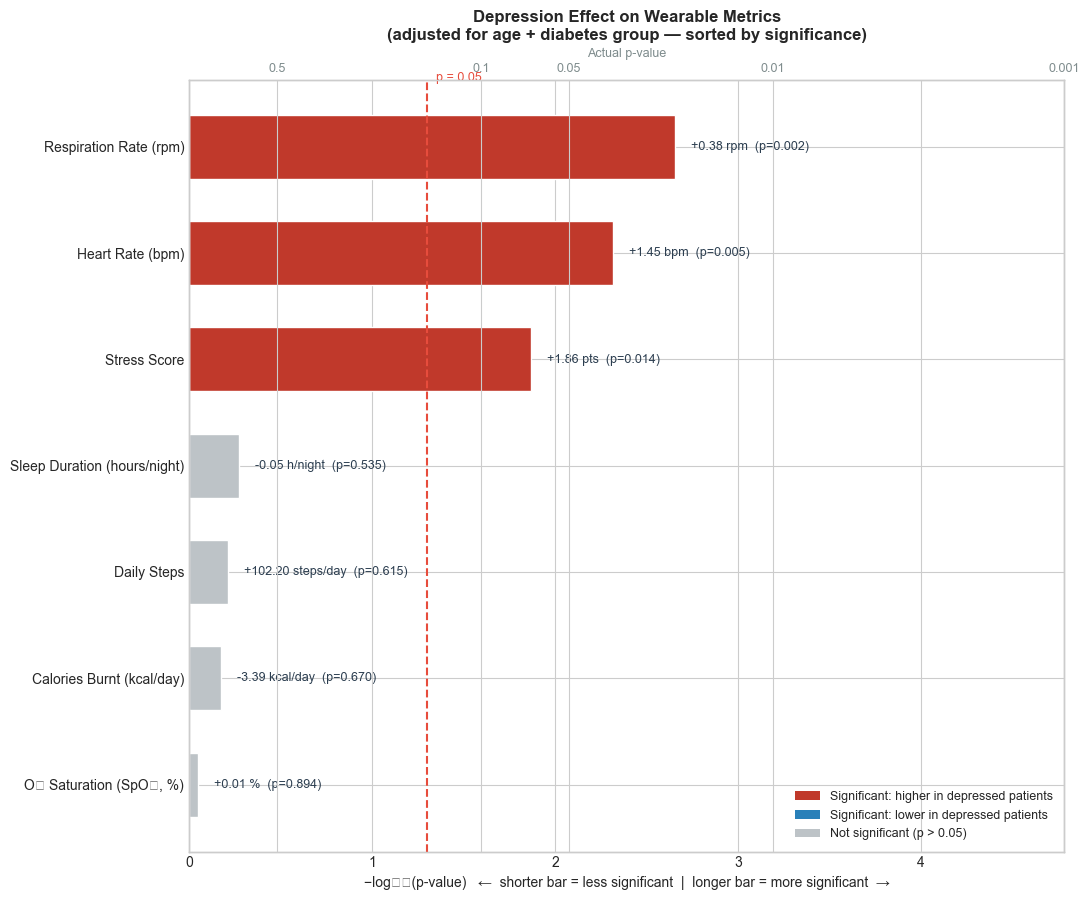

In [27]:

# ── Analysis 5: Regression ──────────────────────────────────────────

if not AVAILABLE_METRICS:
    print('⚠️  No wearable metrics available — skipping Analysis 5.')
else:
    print('=== OLS Regression: metric ~ depressed + group_code + age_std ===')
    reg_results = []

    for metric, label in AVAILABLE_METRICS.items():
        sub = df.dropna(subset=[metric, 'depressed', 'study_group_code', 'age_std']).copy()
        if len(sub) < 50:
            continue

        mod_a = smf.ols(f'{metric} ~ depressed + study_group_code + age_std', data=sub).fit()
        mod_b = smf.ols(f'{metric} ~ depressed * study_group_code + age_std', data=sub).fit()

        dep_coef    = mod_a.params.get('depressed', np.nan)
        dep_p       = mod_a.pvalues.get('depressed', np.nan)
        grp_coef    = mod_a.params.get('study_group_code', np.nan)
        age_coef    = mod_a.params.get('age_std', np.nan)
        int_p       = mod_b.pvalues.get('depressed:study_group_code', np.nan)
        metric_sd   = sub[metric].std()
        dep_std_coef = dep_coef / metric_sd if metric_sd > 0 else np.nan

        stars     = '***' if dep_p < 0.001 else '**' if dep_p < 0.01 else '*' if dep_p < 0.05 else 'ns'
        int_stars = ('***' if int_p < 0.001 else '**' if int_p < 0.01
                     else '*' if int_p < 0.05 else 'ns') if not np.isnan(int_p) else '—'

        print(f'\n── {label} (n={len(sub):,}) ──')
        print(f'  R²={mod_a.rsquared:.4f}')
        print(f'  depressed  raw coef={dep_coef:+.3f}  std β={dep_std_coef:+.3f}  p={dep_p:.4f}  {stars}')
        print(f'  group_code coef={grp_coef:.3f}  p={mod_a.pvalues.get("study_group_code", np.nan):.4f}')
        print(f'  age_std    coef={age_coef:.3f}  p={mod_a.pvalues.get("age_std", np.nan):.4f}')
        print(f'  Interaction (dep × group) p={int_p:.4f}  {int_stars}'
              if not np.isnan(int_p) else '  Interaction: not estimable')

        reg_results.append({
            'metric': metric, 'label': label, 'n': len(sub),
            'r2':           round(mod_a.rsquared, 4),
            'dep_coef':     round(dep_coef, 3),
            'dep_std_coef': round(dep_std_coef, 4),
            'dep_p':        round(dep_p, 4),
            'dep_sig':      dep_p < 0.05,
            'interaction_p':   round(int_p, 4) if not np.isnan(int_p) else np.nan,
            'interaction_sig': int_p < 0.05 if not np.isnan(int_p) else False,
        })

    print('\n=== Regression Summary ===')
    reg_df = pd.DataFrame(reg_results)
    if len(reg_df) > 0:
        print(reg_df[['label', 'n', 'r2', 'dep_coef', 'dep_std_coef',
                       'dep_p', 'dep_sig', 'interaction_p', 'interaction_sig']]
              .to_string(index=False))

    # ── Significance chart ─────────────────────────────────────────
    # Bars show −log₁₀(p-value).
    #   → smaller p-value  =  longer bar  =  more significant
    #   → larger  p-value  =  shorter bar =  less significant
    # Bars are sorted longest (most significant) to shortest.
    # Color: red = depression raises this metric, blue = lowers it, gray = not significant.
    if len(reg_df) > 0:
        UNIT_MAP = {
            'daily_steps':          'steps/day',
            'daily_calories':       'kcal/day',
            'sleep_duration_hours': 'h/night',
            'avg_stress':           'pts',
            'avg_spo2':             '%',
            'avg_heart_rate':       'bpm',
            'avg_respiration':      'rpm',
        }

        plot_df = reg_df.copy()
        plot_df['neg_log_p'] = -np.log10(plot_df['dep_p'].clip(lower=1e-10))
        plot_df = plot_df.sort_values('neg_log_p', ascending=True)  # top = most significant

        colors = [
            '#C0392B' if (row.dep_sig and row.dep_coef > 0)
            else '#2980B9' if (row.dep_sig and row.dep_coef < 0)
            else '#BDC3C7'
            for _, row in plot_df.iterrows()
        ]

        sig_line = -np.log10(0.05)   # 1.30

        fig, ax = plt.subplots(figsize=(11, max(4, len(plot_df) * 1.3)))
        bars = ax.barh(
            plot_df['label'].apply(lambda x: x[:42]),
            plot_df['neg_log_p'],
            color=colors, edgecolor='white', height=0.6
        )

        # Significance threshold line
        ax.axvline(sig_line, color='#E74C3C', linewidth=1.5, linestyle='--', zorder=3)
        ax.text(sig_line + 0.05, len(plot_df) - 0.3, 'p = 0.05',
                color='#E74C3C', fontsize=9, va='top')

        # Annotate each bar: raw effect + p-value
        x_max = plot_df['neg_log_p'].max()
        for bar, (_, row) in zip(bars, plot_df.iterrows()):
            unit   = UNIT_MAP.get(row['metric'], '')
            sign   = '+' if row['dep_coef'] > 0 else ''
            p_str  = f'p={row["dep_p"]:.3f}' if row['dep_p'] >= 0.001 else 'p<0.001'
            note   = f'  {sign}{row["dep_coef"]:.2f} {unit}  ({p_str})'
            ax.text(bar.get_width() + 0.05,
                    bar.get_y() + bar.get_height() / 2,
                    note, va='center', ha='left', fontsize=9, color='#2C3E50')

        # Secondary x-axis: actual p-value labels at key positions
        p_ticks   = [0.001, 0.01, 0.05, 0.1, 0.5]
        x_ticks   = [-np.log10(p) for p in p_ticks]
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(x_ticks)
        ax2.set_xticklabels([str(p) for p in p_ticks], fontsize=9, color='#7F8C8D')
        ax2.set_xlabel('Actual p-value', fontsize=9, color='#7F8C8D')

        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor='#C0392B', label='Significant: higher in depressed patients'),
            Patch(facecolor='#2980B9', label='Significant: lower in depressed patients'),
            Patch(facecolor='#BDC3C7', label='Not significant (p > 0.05)'),
        ], fontsize=9, loc='lower right')

        ax.set_xlabel('−log₁₀(p-value)   ←  shorter bar = less significant  |  '
                      'longer bar = more significant  →', fontsize=10)
        ax.set_title('Depression Effect on Wearable Metrics\n'
                     '(adjusted for age + diabetes group — sorted by significance)',
                     fontsize=12, fontweight='bold')
        ax.set_xlim(0, x_max * 1.8)
        ax.tick_params(axis='y', labelsize=10)
        plt.tight_layout()
        plt.show()


---
## 13. Analysis 6 — Continuous CES-D-10 Score × Wearable Metrics

> **Question**: Analyses 1–5 split patients into depressed vs non-depressed at the CES-D-10 ≥ 10
> cutoff, which discards the depression *severity* gradient (a score of 0 and 9 are both "not
> depressed"; 10 and 30 are both "depressed"). Does each wearable metric track *continuously*
> with the full 0–30 symptom score, using every scored participant instead of a 20/80 split?
>
> **Method**: Spearman rank correlation between the continuous `cesd_total` score and each of the
> 7 wearable metrics — overall and within each diabetes group — with FDR correction
> (Benjamini-Hochberg) across metrics. **Activity** metrics (steps, calories — what a person
> *chooses* to do) are flagged separately from **physiological** state metrics (stress, heart
> rate, respiration, SpO₂, sleep). This complements, rather than replaces, the binary analyses.

=== Overall: Spearman correlation (continuous CES-D-10 vs wearable metric) ===
(rho > 0 = metric rises as depressive symptoms rise)
                       label          kind    n    rho     p  p_fdr  significant
            Heart Rate (bpm) Physiological 1984  0.147 0.000  0.000         True
                Stress Score Physiological 1984  0.109 0.000  0.000         True
                 Daily Steps      Activity 2138  0.068 0.002  0.004         True
      Respiration Rate (rpm) Physiological 1757  0.063 0.008  0.015         True
   Calories Burnt (kcal/day)      Activity 2181  0.038 0.076  0.107        False
Sleep Duration (hours/night) Physiological 2004 -0.026 0.237  0.276        False
     O₂ Saturation (SpO₂, %) Physiological 1626 -0.013 0.605  0.605        False

=== By diabetes group (Spearman rho; * = p < 0.05 within group) ===
                       label          kind Healthy Pre-DM Oral Med Insulin
                 Daily Steps      Activity   +0.06  +0.03   +0.09*  +0.16*
 

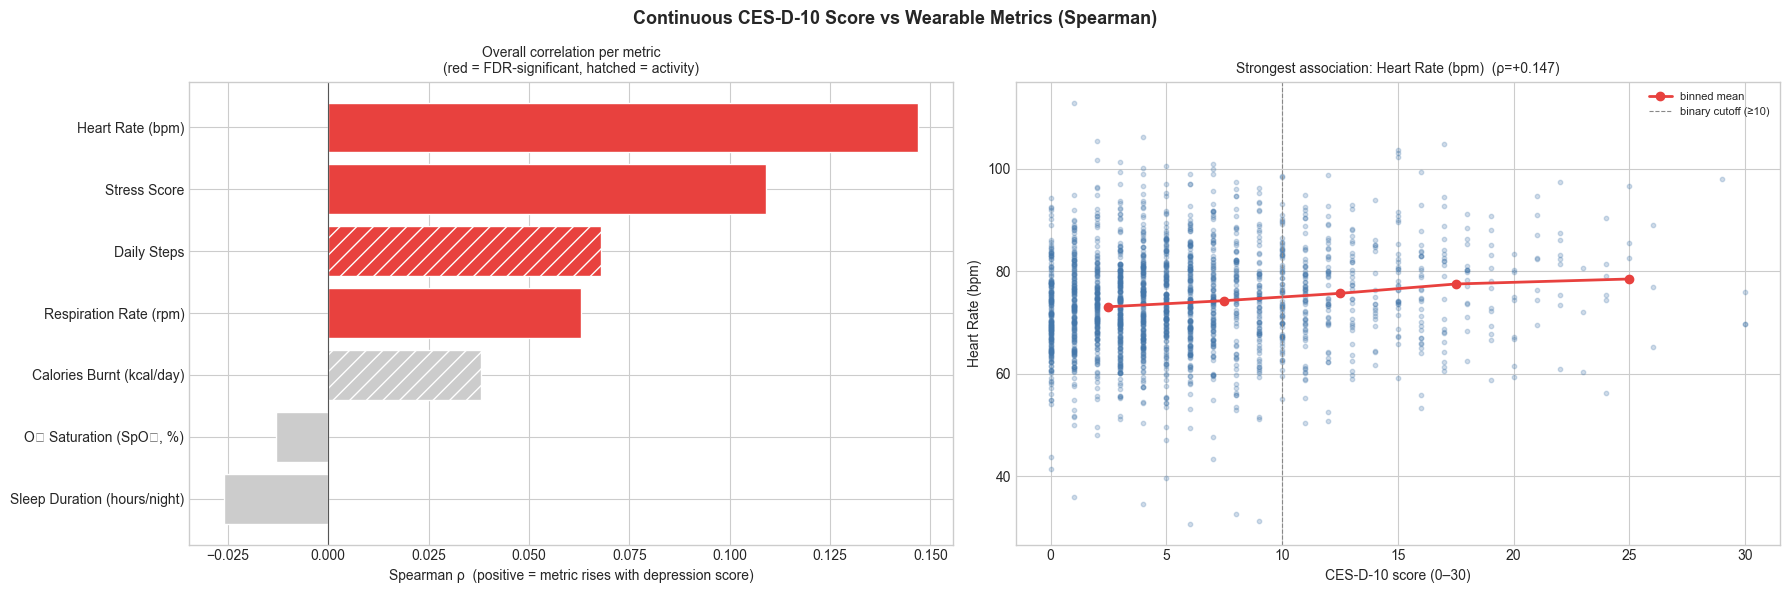

In [28]:
# ── Analysis 6: Continuous CES-D-10 × Wearable Correlation ──────────
# Severity-graded view: correlate the full 0–30 CES-D-10 score with each metric,
# instead of the binary >=10 split used in Analyses 1–5.

ACTIVITY_METRICS = {'daily_steps', 'daily_calories'}   # "what a person chooses to do"

if not AVAILABLE_METRICS or 'cesd_total' not in df.columns:
    print('⚠️  CES-D-10 score or wearable metrics unavailable — skipping Analysis 6.')
else:
    # ── Overall Spearman: cesd_total vs each metric ──
    corr_records = []
    for metric, label in AVAILABLE_METRICS.items():
        sub = df[['cesd_total', metric]].dropna()
        if len(sub) < 20:
            continue
        rho, pval = spearmanr(sub['cesd_total'], sub[metric])
        corr_records.append({
            'metric': metric, 'label': label,
            'kind': 'Activity' if metric in ACTIVITY_METRICS else 'Physiological',
            'n': len(sub), 'rho': round(rho, 3), 'p': round(pval, 5),
        })
    corr_df = pd.DataFrame(corr_records)
    _, corr_df['p_fdr'], _, _ = multipletests(corr_df['p'], method='fdr_bh')
    corr_df['p_fdr'] = corr_df['p_fdr'].round(4)
    corr_df['significant'] = corr_df['p_fdr'] < 0.05
    corr_df = corr_df.sort_values('rho', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

    print('=== Overall: Spearman correlation (continuous CES-D-10 vs wearable metric) ===')
    print('(rho > 0 = metric rises as depressive symptoms rise)')
    print(corr_df[['label', 'kind', 'n', 'rho', 'p', 'p_fdr', 'significant']].to_string(index=False))

    # ── By diabetes group ──
    print('\n=== By diabetes group (Spearman rho; * = p < 0.05 within group) ===')
    grp_records = []
    for metric, label in AVAILABLE_METRICS.items():
        row = {'label': label,
               'kind': 'Activity' if metric in ACTIVITY_METRICS else 'Physiological'}
        for grp in STUDY_GROUP_ORDER:
            sub = df[df['study_group_label'] == grp][['cesd_total', metric]].dropna()
            if len(sub) < 20:
                row[grp] = 'n/a'
                continue
            rho, pval = spearmanr(sub['cesd_total'], sub[metric])
            row[grp] = f"{rho:+.2f}{'*' if pval < 0.05 else ''}"
        grp_records.append(row)
    grp_df = pd.DataFrame(grp_records)
    print(grp_df.to_string(index=False))

    # ── Visualisation ──
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Continuous CES-D-10 Score vs Wearable Metrics (Spearman)',
                 fontsize=13, fontweight='bold')

    # Panel A: rho bar chart, red = FDR-significant, hatched = activity metric
    cdf = corr_df.sort_values('rho')
    bar_colors = ['#E8413E' if s else '#cccccc' for s in cdf['significant']]
    bars = axes[0].barh(cdf['label'], cdf['rho'], color=bar_colors, edgecolor='white')
    for bar, kind in zip(bars, cdf['kind']):
        if kind == 'Activity':
            bar.set_hatch('//')
    axes[0].axvline(0, color='#555', linewidth=0.8)
    axes[0].set_xlabel('Spearman ρ  (positive = metric rises with depression score)')
    axes[0].set_title('Overall correlation per metric\n'
                      '(red = FDR-significant, hatched = activity)', fontsize=10)

    # Panel B: scatter + binned trend for the strongest-correlating metric
    top_metric = corr_df.iloc[0]['metric']
    top_label  = corr_df.iloc[0]['label']
    sub = df[['cesd_total', top_metric]].dropna().copy()
    axes[1].scatter(sub['cesd_total'], sub[top_metric], s=10, alpha=0.25, color='#4477AA')
    sub['cesd_bin'] = pd.cut(sub['cesd_total'], bins=[0, 5, 10, 15, 20, 30], right=False)
    binned  = sub.groupby('cesd_bin', observed=True)[top_metric].mean()
    centers = [2.5, 7.5, 12.5, 17.5, 25][:len(binned)]
    axes[1].plot(centers, binned.values, color='#E8413E', marker='o',
                 linewidth=2, label='binned mean')
    axes[1].axvline(10, color='#888', linestyle='--', linewidth=0.8,
                    label='binary cutoff (≥10)')
    axes[1].set_xlabel('CES-D-10 score (0–30)')
    axes[1].set_ylabel(top_label)
    axes[1].set_title(f'Strongest association: {top_label}  '
                      f'(ρ={corr_df.iloc[0]["rho"]:+.3f})', fontsize=10)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

---
## Key Findings
> Full interpretation: `reports/31_depression_wearable_signals/`

**Depression's wearable signature here is physiological arousal — higher resting heart rate, stress, and respiration — not behavioral slowing. The signal is clearest in non-diabetics and flat across age.**

### Coverage
- n = 2,280 | CES-D-10: 2,277 (99.9%) | Depressed (≥10): 455 (20.0%)
- Metric coverage 71–96%: steps 2,141 · calories 2,184 · sleep 2,007 · stress 1,987 · SpO₂ 1,628 · heart rate 1,987 · respiration 1,760

1. **Overall (Analysis 1):** 3 of 7 metrics significantly elevated in depressed patients — stress (+3.0 pts, p<0.001), heart rate (+2.95 bpm, p<0.001), respiration (+0.37 rpm, p=0.011). Steps, calories, sleep, and SpO₂ are not different — and steps actually trend **+544 higher** in depressed (ns). No "moves less" signal.

2. **By group (Analysis 2):** significant gaps appear in **Healthy** (stress, HR, respiration) and **Pre-DM** (stress, HR) — not Oral Med or Insulin (Insulin underpowered, n=79 depressed, but directionally consistent). The Healthy-group result confirms these are direct depression→physiology effects, not mediated by diabetes burden. This is the *opposite* of NB30's glycemic gap, which was largest in Insulin.

3. **By age (Analysis 3):** gaps are positive in all four age bands but none individually significant; the effect is essentially **flat across age** — unlike the age gradients in NB29/NB30.

4. **Stratified (Analysis 4):** no age × group cell survives FDR correction — expected at this sample size.

5. **Regression (Analysis 5):** after adjusting for age + diabetes group, depression **independently predicts** respiration (+0.38 rpm, p=0.002), heart rate (+1.45 bpm, p=0.005), and stress (+1.86 pts, p=0.014). Effects are **uniform across groups** (no group × depression interaction). Sleep shows a group × depression interaction (p=0.038) despite no main effect.

6. **Continuous correlation (Analysis 6):** the full 0–30 CES-D-10 score correlates significantly with heart rate (ρ=+0.147), stress (+0.109), steps (+0.068), and respiration (+0.063) — all FDR-significant, all weak (|ρ| ≤ 0.15). This shows the arousal markers rise **gradually** with symptom load, not just above the ≥10 cutoff. The step correlation is **positive** (more symptoms ↔ slightly more steps), opposite the "moves less" expectation. By group: heart rate correlates in Healthy/Oral Med/Insulin; stress and respiration only in Healthy.

**Key takeaway:** Depression maps to a chronic physiological-arousal pattern (elevated resting heart rate, stress index, respiration) that is consistent across age and diabetes severity and is *not* accompanied by reduced movement or sleep. Screening/care pathways might monitor resting HR and stress indices as physiological correlates of depression.